In [12]:
# ============================================================================
# Alpha Comparison Analysis
# ============================================================================
import mne
from xeeg_kit import load_bel_channel_map, select_channels, plot_comparison



In [13]:
# Load Data

CLOSED_FILE = "/mnt/movement/users/jaizor/xtra/derivatives/eeg/rest/clean/sub-01/rest_off/rest_off_sub-01_c_eeg_mkit_cleaned.fif"  
OPEN_FILE = "/mnt/movement/users/jaizor/xtra/derivatives/eeg/rest/clean/sub-01/rest_off/rest_off_sub-01_o_eeg_mkit_cleaned.fif"    


fif_ec = mne.io.read_raw(CLOSED_FILE, preload=True, verbose=False)
fif_eo = mne.io.read_raw(OPEN_FILE, preload=True, verbose=False)

In [14]:
# Load Map & Inspect Occipital Channels


map_df = load_bel_channel_map() 
occipital_chs = map_df[map_df['region'] == 'Occipital']['name'].tolist()
print(occipital_chs)

📂 Loading bundled map from: /mnt/movement/users/jaizor/.local/lib/python3.13/site-packages/xeeg_kit/data/bel_280_channel_map.csv
['E104', 'E105', 'E106', 'E107', 'E108', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E124', 'E125', 'E126', 'E127', 'E128', 'E129', 'E130', 'E133', 'E141', 'E142', 'E150', 'E151', 'E152', 'E153', 'E163', 'E193', 'E194', 'E195', 'E196', 'E197', 'E198', 'E201', 'E202', 'E203', 'E204', 'E205', 'E206', 'E207', 'E212', 'E213', 'E214', 'E215', 'E216', 'E217']


In [15]:
# Select Specific Channels MANUALLY

# 👇 REPLACE these with the 4-5 names you saw in the Occipital list above
my_manual_channels = ['E104', 'E105', 'E106', 'E107'] 


my_chs = select_channels(
    raw_data=fif_ec,      
    map_df=None,          
    method="manual", 
    manual_list=my_manual_channels
)

print(my_chs)

🎯 Selected 4 channels using method 'manual'.
['E104', 'E105', 'E106', 'E107']



4. Generating Comparison Plot...


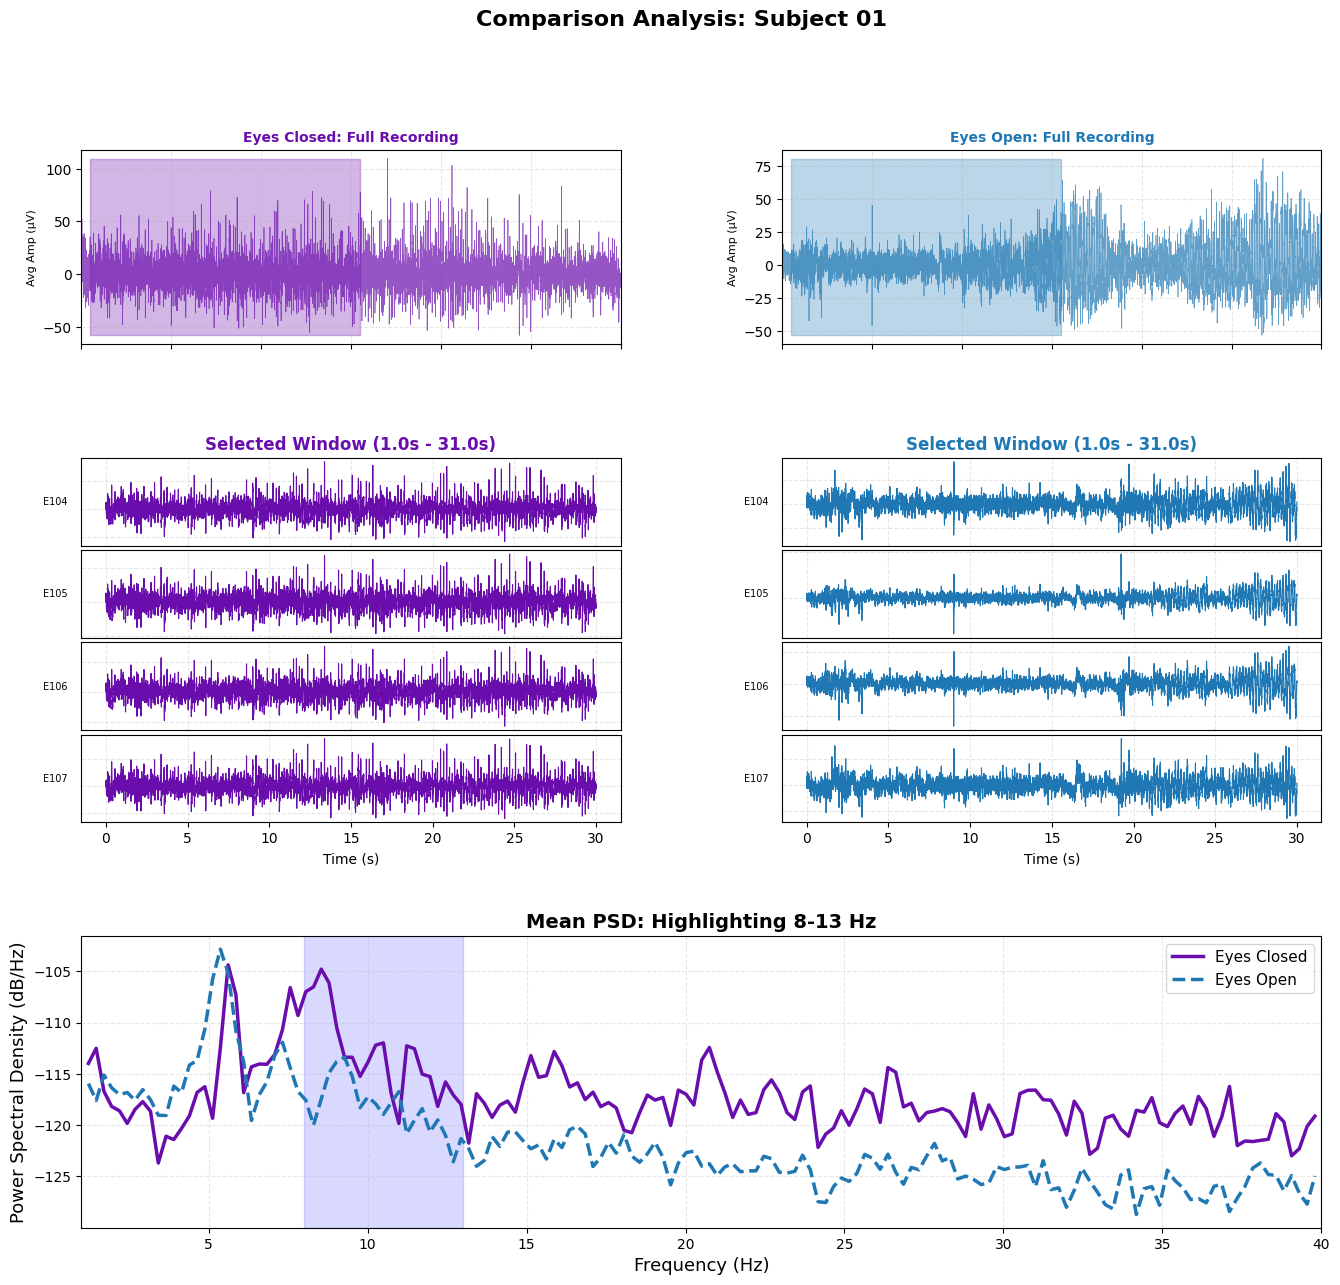

In [16]:
# Run the Comparison Plot

print("\n4. Generating Comparison Plot...")
plot_comparison(
    eeg_input_1=fif_ec,      
    eeg_input_2=fif_eo,      
    ch_names=my_chs,         
    start_1=1.0,                  
    dur_1=30.0,                   
    start_2=1.0,                  
    dur_2=30.0,                   
    subject_id="01",
    label_1="Eyes Closed",        
    label_2="Eyes Open",          
    freq_band=[8, 13],            
    band_color='blue',          
    band_alpha=0.15,
    save_plot=False               
)